# Extração de Informações e Pré-processamento

##### 1 — Imports

In [37]:
import os
import re
import pandas as pd
from tqdm import tqdm

##### 2 — Caminhos dos dados

In [38]:
BASE_PATH = "../data/raw/"

CONTROL_PATH = os.path.join(BASE_PATH, "control")
DEMENTIA_PATH = os.path.join(BASE_PATH, "dementia")

##### 3 — Função para ler .cha

In [39]:
def extract_par_text(file_path):
    text = []
    
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("*PAR:"):
                # remove "PAR:"
                line = line.replace("PAR:", "").strip()
                text.append(line)
    
    return " ".join(text)

##### 4 — Limpeza básica

In [40]:
def clean_text(text):
    
    # remove símbolos CHAT
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\[.*?\]", "", text)
    
    # remove caracteres estranhos tipo \x15
    text = re.sub(r"\x15.*?\x15", "", text)
    
    # remove \t (TAB)
    text = text.replace("\t", " ")
    
    # remove caracteres não alfabéticos
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # lower
    text = text.lower()
    
    return text

##### 5 — Criar dataset

In [41]:
data = []

# CONTROL (classe 0)
for file in tqdm(os.listdir(CONTROL_PATH)):
    file_path = os.path.join(CONTROL_PATH, file)
    
    text = extract_par_text(file_path)
    text = clean_text(text)
    
    data.append({
        "id": file,
        "text": text,
        "label": 0
    })


# DEMENTIA (classe 1)
for file in tqdm(os.listdir(DEMENTIA_PATH)):
    file_path = os.path.join(DEMENTIA_PATH, file)
    
    text = extract_par_text(file_path)
    text = clean_text(text)
    
    data.append({
        "id": file,
        "text": text,
        "label": 1
    })


df = pd.DataFrame(data)
df.head()

100%|██████████| 306/306 [00:00<00:00, 3084.34it/s]


,id,text,label
0,002-0.cha,the scene is in the kitchen the mother i...,0
1,002-1.cha,oh i see the sink is running over i see th...,0
2,002-2.cha,um a boy and a girl are in the kitchen with t...,0
3,002-3.cha,okay it was summertime and mother and the ...,0
4,006-2.cha,clearsthroat wait until i put my glasses on ...,0


##### 6 — Verificação

In [43]:
df.shape

df['label'].value_counts()

df.sample(5)

df.to_parquet("../data/processed/dataset.parquet")

# Engenharia de Features

### Criação das features

##### 1 — Features básicas de texto

In [ ]:
# Número de palavras
df["num_words"] = df["text"].apply(lambda x: len(x.split()))

# Palavras únicas
df["num_unique_words"] = df["text"].apply(lambda x: len(set(x.split())))

# Diversidade lexical
df["lexical_diversity"] = df["num_unique_words"] / df["num_words"]

##### 2 — Fluência na fala

In [ ]:
def count_hesitations(text):
    hesitations = ["uh", "um", "er", "ah"]
    words = text.split()
    return sum(w in hesitations for w in words)

df["hesitations"] = df["text"].apply(count_hesitations)

##### 3 — Complexidade do discurso

In [ ]:
# Comprimento médio das palavras
df["avg_word_length"] = df["text"].apply(
    lambda x: sum(len(w) for w in x.split()) / len(x.split()) if len(x.split()) > 0 else 0
)

##### 4 — Verificação das features

In [ ]:
df.head()

,id,text,label,num_words,num_unique_words,lexical_diversity,hesitations,avg_word_length
0,002-0.cha,the scene is in the kitchen the mother i...,0,138,85,0.615942,5,4.043478
1,002-1.cha,oh i see the sink is running over i see th...,0,96,54,0.562500,0,4.208333
2,002-2.cha,um a boy and a girl are in the kitchen with t...,0,156,88,0.564103,7,4.019231
3,002-3.cha,okay it was summertime and mother and the ...,0,170,98,0.576471,4,4.305882
4,006-2.cha,clearsthroat wait until i put my glasses on ...,0,96,62,0.645833,5,3.937500


### Validação das features

##### 1 — Comparação por classe

In [ ]:
df.groupby("label")[[
    "num_words",
    "lexical_diversity",
    "hesitations",
    "avg_word_length"
]].mean()

,num_words,lexical_diversity,hesitations,avg_word_length
label,,,,
0,106.016529,0.639787,3.115702,3.990635
1,94.421569,0.646740,2.973856,3.883922


##### 2 — Visualização

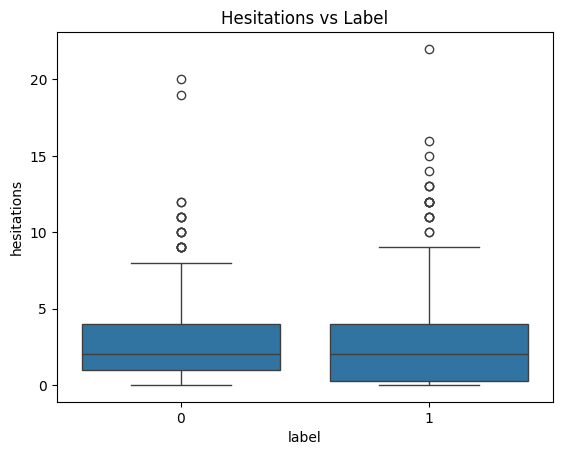

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="label", y="hesitations", data=df)
plt.title("Hesitations vs Label")
plt.show()

# Treinamento do Modelo

##### 1 — Preparar dados

In [ ]:
features = [
    "num_words",
    "num_unique_words",
    "lexical_diversity",
    "hesitations",
    "avg_word_length"
]

X = df[features]
y = df["label"]

##### 2 — Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##### 3 — Modelo simples (baseline)

###### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Avaliação

##### 1 — Avaliação

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.47      0.55        49
           1       0.65      0.80      0.72        61

    accuracy                           0.65       110
   macro avg       0.66      0.64      0.63       110
weighted avg       0.66      0.65      0.64       110



##### 2 — Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6545454545454545